In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Polygon

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True

RESULTS_DIR = Path("01-RESULTS")
SCENARIO = "with_battery"          # match config.scenario
START_TAG = "04-01_12-00"          # match config.start_time

# Find all duration folders for this scenario+start
pattern = f"multi_ts_{SCENARIO}_{START_TAG}_d*h"
run_dirs = sorted(RESULTS_DIR.glob(pattern),
                  key=lambda p: int(p.name.split("_d")[-1].rstrip("h")))

print(f"Found {len(run_dirs)} duration runs:")
for d in run_dirs:
    print(f"  {d.name}")

Found 4 duration runs:
  multi_ts_with_battery_04-01_12-00_d1h
  multi_ts_with_battery_04-01_12-00_d2h
  multi_ts_with_battery_04-01_12-00_d4h
  multi_ts_with_battery_04-01_12-00_d8h


In [19]:
def load_all(filename: str) -> pd.DataFrame:
    """Concatenate `filename` across all duration folders."""
    dfs = []
    for d in run_dirs:
        f = d / filename
        if not f.exists():
            print(f"  ⚠ missing: {f}")
            continue
        df = pd.read_csv(f)
        # Belt-and-suspenders: derive duration from folder name if column missing
        if "duration_h" not in df.columns:
            df["duration_h"] = int(d.name.split("_d")[-1].rstrip("h"))
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

vertices = load_all("ffor_vertices.csv")
pcc      = load_all("pcc_results_all_directions.csv")
flex     = load_all("flex_results_all_directions.csv")

# Parse types
for df in (pcc, flex):
    df["time"] = pd.to_datetime(df["time"])
flex["bus"] = flex["bus"].astype(int)

print(f"vertices : {len(vertices):>6} rows  ({sorted(vertices['duration_h'].unique())})")
print(f"pcc      : {len(pcc):>6} rows")
print(f"flex     : {len(flex):>6} rows")
vertices.head()

vertices :    128 rows  ([np.int64(1), np.int64(2), np.int64(4), np.int64(8)])
pcc      :    315 rows
flex     :  39060 rows


,direction_id,duration_h,theta_rad,theta_deg,alpha,beta,status,solver_status,solve_attempt,obj_value,P_flex_pcc,Q_flex_pcc
0,0,1,0.000000,0.00,-1.000000,-0.000000,optimal,ok,default,-0.535772,0.535772,0.092887
1,1,1,0.196350,11.25,-0.980785,-0.195090,optimal,ok,default,-0.555315,0.545574,0.103664
2,2,1,0.392699,22.50,-0.923880,-0.382683,optimal,ok,default,-0.535962,0.516783,0.152913
3,3,1,0.589049,33.75,-0.831470,-0.555570,optimal,ok,default,-0.522370,0.479815,0.222148
4,4,1,0.785398,45.00,-0.707107,-0.707107,optimal,ok,default,-0.504080,0.430042,0.282835


In [20]:
status_summary = (
    vertices
    .groupby(["duration_h", "status"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
print(status_summary)

# List which directions failed for each duration
for d in sorted(vertices["duration_h"].unique()):
    failed = vertices[(vertices["duration_h"] == d) &
                      (vertices["status"] != "optimal")]
    if len(failed):
        print(f"\nd={d}h — failed directions ({len(failed)}):")
        print(failed[["direction_id", "theta_deg", "solver_status"]].to_string(index=False))

status      error  optimal
duration_h                
1               1       31
2               6       26
4              10       22
8              14       18

d=1h — failed directions (1):
 direction_id  theta_deg solver_status
           15     168.75         error

d=2h — failed directions (6):
 direction_id  theta_deg solver_status
            9     101.25         error
           11     123.75         error
           12     135.00         error
           15     168.75         error
           29     326.25         error
           31     348.75         error

d=4h — failed directions (10):
 direction_id  theta_deg solver_status
            9     101.25         error
           10     112.50         error
           11     123.75         error
           12     135.00         error
           13     146.25         error
           14     157.50         error
           15     168.75         error
           22     247.50         error
           26     292.50         error
   

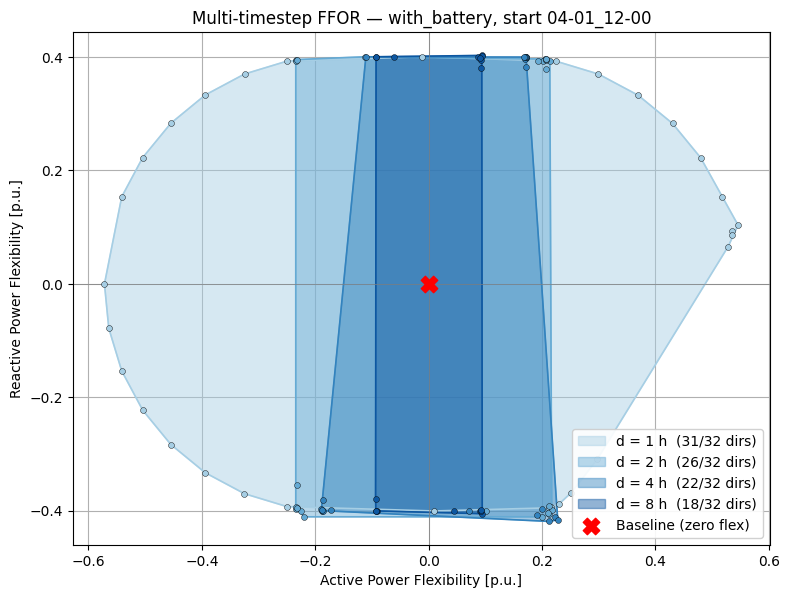

In [21]:
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 8))

durations = sorted(vertices["duration_h"].unique())
# Light → dark blue as duration increases (paper Fig. 6 convention)
colors = cm.Blues(np.linspace(0.35, 0.85, len(durations)))

# Plot LONGEST first so shortest (largest area) ends up on top? No —
# longest is SMALLEST area, so we plot longest LAST to keep it visible inside.
# Actually since shorter durations have LARGER FFORs, plot longest→shortest
# so the small polygons sit visibly inside the larger ones.
for duration_h, color in zip(durations, colors):
    sub = (vertices
           .query("duration_h == @duration_h and status == 'optimal'")
           .sort_values("theta_deg"))

    pts = sub[["P_flex_pcc", "Q_flex_pcc"]].values
    if len(pts) < 3:
        continue

    # Convex hull of the sampled support points = FFOR estimate
    hull = Polygon(pts).convex_hull
    hx, hy = hull.exterior.xy

    ax.fill(hx, hy, color=color, alpha=0.45,
            label=f"d = {duration_h} h  ({len(sub)}/{config_n_dirs if False else 32} dirs)")
    ax.plot(hx, hy, color=color, lw=1.2)
    ax.scatter(pts[:, 0], pts[:, 1], color=color, s=18, zorder=3,
               edgecolors="black", linewidths=0.3)

# Baseline marker (FFOR is centered at origin by definition, paper Sec II-C1)
ax.scatter(0, 0, c="red", s=140, marker="X", zorder=5,
           label="Baseline (zero flex)")

ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("Active Power Flexibility [p.u.]")
ax.set_ylabel("Reactive Power Flexibility [p.u.]")
ax.set_title(f"Multi-timestep FFOR — {SCENARIO}, start {START_TAG}")
ax.set_aspect("equal")
ax.legend(loc="best", framealpha=0.9)
plt.tight_layout()
plt.show()

 duration_h  P_flex_pos  P_flex_neg  Q_flex_pos  Q_flex_neg
          1    0.545574   -0.571610    0.400457   -0.400459
          2    0.217018   -0.234303    0.400442   -0.410716
          4    0.227658   -0.189050    0.400379   -0.418867
          8    0.094536   -0.093558    0.402784   -0.405212


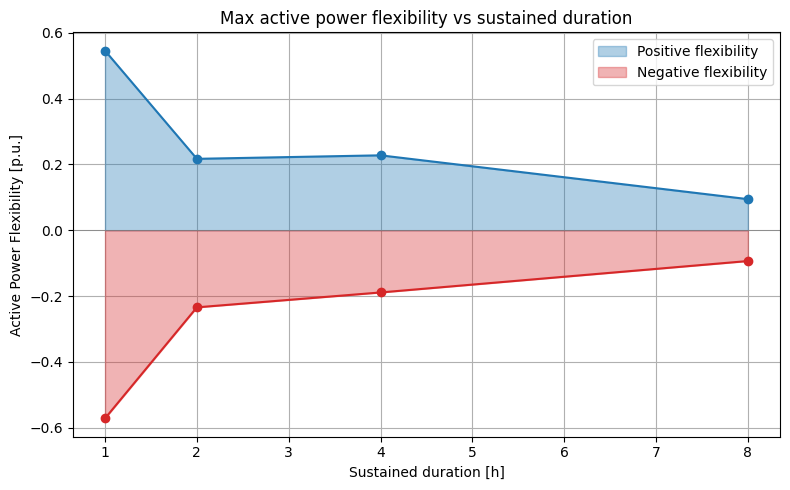

In [22]:
# For each duration, pull the extreme P-flex (positive and negative)
extents = (
    vertices
    .query("status == 'optimal'")
    .groupby("duration_h")
    .agg(P_flex_pos=("P_flex_pcc", "max"),
         P_flex_neg=("P_flex_pcc", "min"),
         Q_flex_pos=("Q_flex_pcc", "max"),
         Q_flex_neg=("Q_flex_pcc", "min"))
    .reset_index()
    .sort_values("duration_h")
)
print(extents.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(extents["duration_h"], 0, extents["P_flex_pos"],
                color="C0", alpha=0.35, label="Positive flexibility")
ax.fill_between(extents["duration_h"], extents["P_flex_neg"], 0,
                color="C3", alpha=0.35, label="Negative flexibility")
ax.plot(extents["duration_h"], extents["P_flex_pos"], "o-", color="C0")
ax.plot(extents["duration_h"], extents["P_flex_neg"], "o-", color="C3")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Sustained duration [h]")
ax.set_ylabel("Active Power Flexibility [p.u.]")
ax.set_title("Max active power flexibility vs sustained duration")
ax.legend()
plt.tight_layout()
plt.show()